<a href="https://colab.research.google.com/github/SagnikMandal121/AI-workforce-/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SagnikMandal121/Flyrank_ML_internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

# Lane Choice

I chose the **Refresh / Content Opportunity Scoring** lane.

The goal is to help content teams decide which pages should be reviewed first for refresh, expansion, monitoring, or optimization. Since organizations often manage hundreds or thousands of pages, manually prioritizing them is difficult and inconsistent. A ranked review queue can help focus limited editorial resources on pages with the highest potential impact.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

# Research Question

Which content pages should be reviewed first for refresh or optimization based on observable search and engagement signals?

## Decision
Prioritize pages for content review and refresh.

## Action
The content or SEO team reviews the highest-ranked pages and decides whether to refresh, expand, protect, prune, or monitor them.

## Cost of a Wrong Recommendation
False positives waste editorial time and resources on pages that may not benefit from intervention.

False negatives are also costly because valuable opportunities for recovery or growth may be missed.

## Why ML Helps
Large content inventories make manual prioritization difficult. ML can help rank pages by likely opportunity while still allowing human review before action is taken.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)
# Quick Look at the Data

The starter dataset contains **30,000** content pages across **44** features.

The average page received approximately **5,200** impressions over the last 90 days, while the average CTR is **0.51**.

Around **16,262** pages are currently trending downward, and **16,726** pages have more than **500 impressions**, indicating a substantial number of high-visibility pages that may require review and prioritization.

These observations suggest that ranking pages for review is a meaningful problem where data-driven prioritization could improve editorial decision-making.

In [ ]:
!git clone https://github.com/SagnikMandal121/Flyrank_ML_internship.git

fatal: destination path 'Flyrank_ML_internship' already exists and is not an empty directory.


In [ ]:
%cd Flyrank_ML_internship

/content/Flyrank_ML_internship


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

df = pd.read_csv("./data/raw/content_refresh_anonymized.csv")

print(df.head())

             content_id          client_id  search_volume  competition  \
0  content_304f48230142  client_f369cb89fc           10.0         0.67   
1  content_a1fb4e703a9e  client_4e07408562           90.0         0.01   
2  content_9aa793d4d895  client_7f2253d7e2            0.0         0.00   
3  content_331d6c4de07b  client_19581e27de           10.0         0.00   
4  content_d99b7a2d90ca  client_3fdba35f04            0.0         0.00   

  competition_level   cpc     content_type    main_intent  word_count  \
0              HIGH  2.05  keyword article  transactional      3221.0   
1               LOW  0.05  keyword article  informational      2481.0   
2               LOW  0.00  keyword article  informational      3515.0   
3               LOW  0.00  keyword article     commercial         NaN   
4               LOW  0.00  keyword article  informational      2803.0   

   char_count  ... char_count_tier   ctr  avg_position  engagement_rate  \
0     20457.0  ...     15000-25000  0.76 

In [ ]:
print(f"Total pages: {len(df)}")
print(f"Columns: {len(df.columns)}")

df.describe()

Total pages: 30000
Columns: 44


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [ ]:
print(f"Total pages: {len(df)}")

print(f"Average 90-day impressions: {df['impressions_90d'].mean():.2f}")

print(f"Average CTR: {df['ctr'].mean():.2f}")

print(f"Pages trending down: {(df['trend_direction']=='down').sum()}")

print(f"Pages with more than 500 impressions: {(df['impressions_90d']>=500).sum()}")

Total pages: 30000
Average 90-day impressions: 5200.37
Average CTR: 0.51
Pages trending down: 16262
Pages with more than 500 impressions: 16726


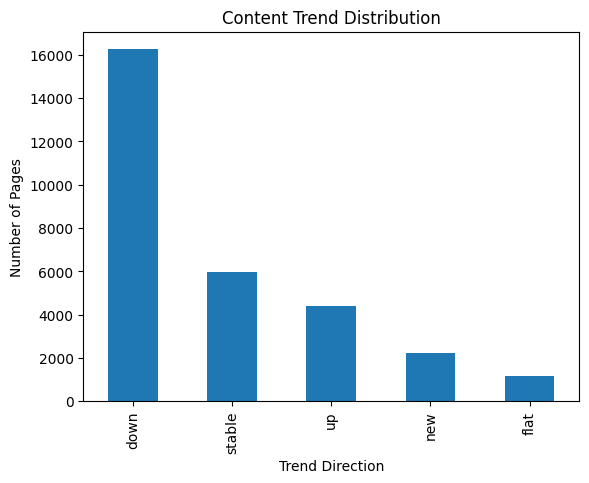

In [ ]:
import matplotlib.pyplot as plt

trend_counts = df["trend_direction"].value_counts()

trend_counts.plot(kind="bar")

plt.title("Content Trend Distribution")
plt.xlabel("Trend Direction")
plt.ylabel("Number of Pages")

plt.show()

In [ ]:
high_visibility = df[df["impressions_90d"] >= 500]

print(f"High visibility pages: {len(high_visibility)}")

print(f"Average CTR of high visibility pages: {high_visibility['ctr'].mean():.2f}")

print(f"Average content age: {high_visibility['content_age_days'].mean():.2f} days")

High visibility pages: 16726
Average CTR of high visibility pages: 0.26
Average content age: 258.95 days


## 4. Careful words: what I can and can't claim

# Careful Words

This project identifies pages that may deserve review based on observable search and engagement signals.

It does **not** prove that refreshing a page will improve rankings or traffic. The results are observational and intended to support human decision-making rather than replace it.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

# Self Check

- ✅ Chosen a project lane
- ✅ Defined a research question
- ✅ Identified the decision and action
- ✅ Explained the cost of a wrong recommendation
- ✅ Supported the lane with real numbers from the dataset
- ✅ Used careful, non-causal language